In [1]:
! pip install faraway

### Step 0

In [2]:
# CodeGrade step0

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve



### Step 1

*  [Data](https://rdrr.io/cran/faraway/man/pima.html)
*  [Faraway](https://pypi.org/project/faraway/)

In [3]:
# CodeGrade step0

# Load the Dataset from faraway
from faraway.datasets import pima

# Load the dataset
data = pima.load()

# Convert 'diabetes' column to int type to represent classes 0 and 1; remove the handful of 2s (unkown) in the data
data['diabetes'] = data['diabetes'].astype(int)
data = data[data['diabetes'] != 2]

In [4]:
# Display the first few rows and info
print(data.head())
print(data.info())

   pregnant  glucose  diastolic  triceps  insulin   bmi  diabetes  age  test
0         6      148         72       35        0  33.6         0   50     1
1         1       85         66       29        0  26.6         0   31     0
2         8      183         64        0        0  23.3         0   32     1
3         1       89         66       23       94  28.1         0   21     0
5         5      116         74        0        0  25.6         0   30     0
<class 'pandas.core.frame.DataFrame'>
Index: 764 entries, 0 to 767
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pregnant   764 non-null    int64  
 1   glucose    764 non-null    int64  
 2   diastolic  764 non-null    int64  
 3   triceps    764 non-null    int64  
 4   insulin    764 non-null    int64  
 5   bmi        764 non-null    float64
 6   diabetes   764 non-null    int64  
 7   age        764 non-null    int64  
 8   test       764 non-null    int64  

In [5]:
# CodeGrade step1

# Shape
data.shape

(764, 9)

### Step 2

In [6]:
# CodeGrade step2

#  Define Features and Scale the Data
# Define features (X) and target (y)
X = data.drop('diabetes', axis=1)
y = data['diabetes']
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset into training (80%) and testing (20%) sets; set seed to 42
# Use the usual naming convention
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Give the shapes separated by commas
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((611, 8), (153, 8), (611,), (153,))

### Step 3


In [9]:
# CodeGrade step3

# Build and Train the Logistic Regression Model
# Instantiate the logistic regression model
# Call this a model
model = LogisticRegression(max_iter=1000)
# Train the model on the training set
model.fit(X_train, y_train)

# Predict probabilities and classes; call these y_pred_proba and y_pred
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Confusion Matrix, call this and then return it as cm
cm = confusion_matrix(y_test, y_pred)
cm            

array([[147,   1],
       [  5,   0]])

### Step 4

In [10]:
# CodeGrade step4

# CAll the classification report "report"; return the precision for '0'

report = classification_report(y_test, y_pred, output_dict=True)

report['0']['precision']

0.9671052631578947

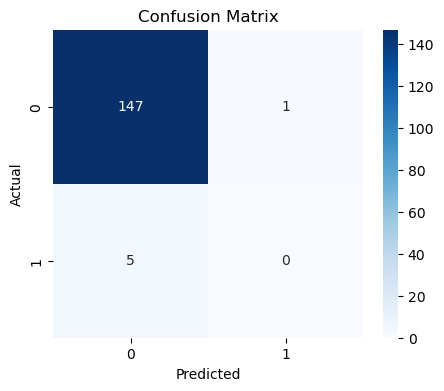

In [11]:
# Visualize Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Step 5

In [12]:
# CodeGrade step5

# Calculate AUC, call this auc
auc = roc_auc_score(y_test, y_pred_proba)

# Calculate ROC curve by finding fpr, tpr, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Return the following
auc, sum(fpr), sum(tpr), sum(thresholds)

(0.6837837837837838,
 np.float64(4.168918918918919),
 np.float64(6.0),
 np.float64(inf))

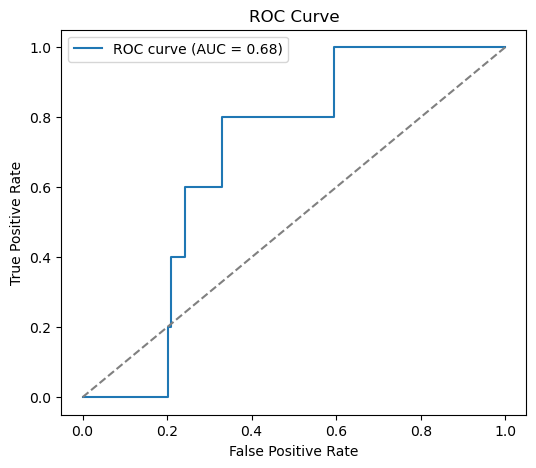

In [13]:
# Print ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()